In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/train.csv
/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/test.csv


In [2]:
import numpy as np # linear algebra
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Datasets :

In [3]:
train_set = pd.read_csv("/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/train.csv")
test_set = pd.read_csv("/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/test.csv")

## Data Inspection :

In [4]:
train_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_set.shape

(891, 12)

In [6]:
train_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train_set.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## Exploratory Data Analysis :

In [8]:
train_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
test_set.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [10]:
train_set['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

- 549 - Non Survived
- 342 - Survived

In [11]:
#print percentage of people who survived by pclass
print("Percentage of Pclass = 1 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 1].value_counts(normalize = True)[1] * 100)

print("Percentage of Pclass = 2 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 2].value_counts(normalize = True)[1] * 100)

print("Percentage of Pclass = 3 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 3].value_counts(normalize = True)[1] * 100)

Percentage of Pclass = 1 who survived: 62.96296296296296
Percentage of Pclass = 2 who survived: 47.28260869565217
Percentage of Pclass = 3 who survived: 24.236252545824847


<Axes: xlabel='Survived', ylabel='count'>

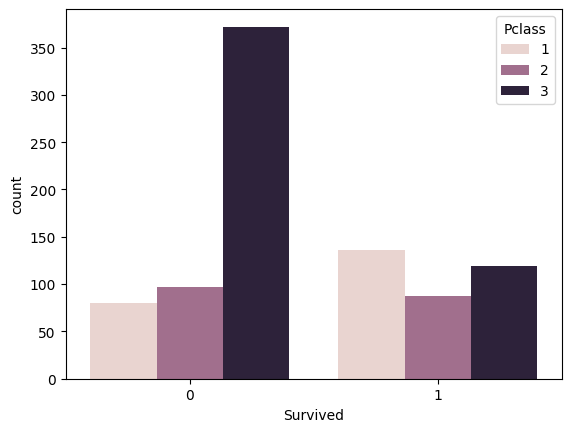

In [12]:
sns.countplot(data = train_set, x = "Survived", hue = "Pclass")

Count of females who survived: 233
Count of females who did not survive: 81
--------------------------------------------
Count of males who survived: 109
Count of males who did not survive: 468


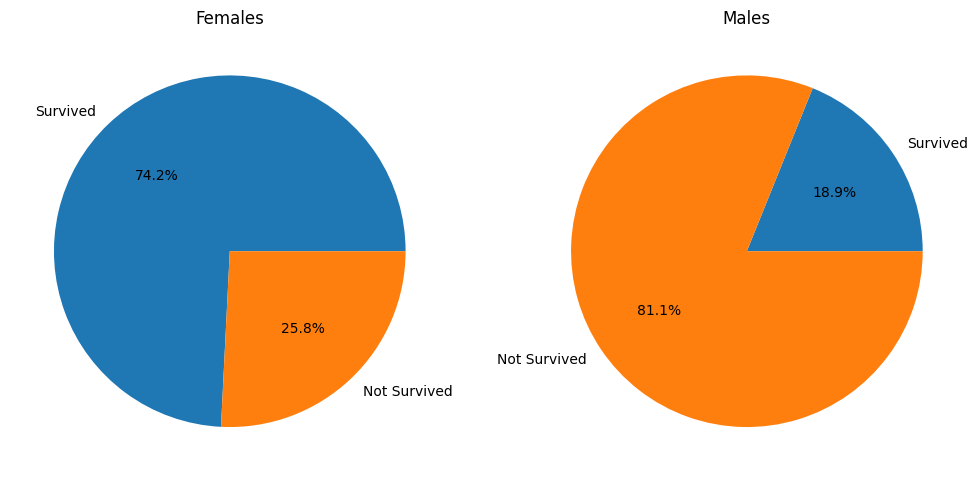

In [13]:
#Count of females who survived and who didnt

female_survived_count = train_set[(train_set['Sex'] == 'female') & (train_set['Survived'] == 1)].shape[0]
female_not_survived_count = train_set[(train_set['Sex'] == 'female') & (train_set['Survived'] == 0)].shape[0]

#Count of males who survived and who didnt
male_survived_count = train_set[(train_set['Sex'] == 'male') & (train_set['Survived'] == 1)].shape[0]
male_not_survived_count = train_set[(train_set['Sex'] == 'male') & (train_set['Survived'] == 0)].shape[0]

print("Count of females who survived:", female_survived_count)
print("Count of females who did not survive:", female_not_survived_count)
print("--------------------------------------------")
print("Count of males who survived:", male_survived_count)
print("Count of males who did not survive:", male_not_survived_count)

#Pie plot for females

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
labels = ['Survived', 'Not Survived']
Sizes = [female_survived_count, female_not_survived_count]
plt.pie(Sizes, labels=labels, autopct = '%1.1f%%')
plt.title('Females')

#Pie plot for males

plt.subplot(1,2,2)
Sizes = [male_survived_count, male_not_survived_count]
plt.pie(Sizes, labels=labels, autopct = '%1.1f%%')
plt.title('Males')

plt.tight_layout()
plt.show()